# TIF: Intención de compra en ecommerce

# 1 - Comprensión del Negocio

**Descripción del Problema**

En un contexto de e‑commerce, actualmente no se puede identificar durante la sesión qué usuarios tienen alta probabilidad de concretar una compra, lo que limita la personalización de incentivos y acciones comerciales en tiempo real.


**Objetivo del proyecto**

Construir un modelo de clasificación binaria que, a partir del comportamiento de navegación de una sesión, prediga si el usuario va a finalizar una compra (`Revenue = True/False`). Esto permite tomar decisiones de negocio proactivas (descuentos, pop-ups, atención personalizada).

# 2 - Comprensión de los Datos

**Dataset**: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

# 2.2 - Diccionario de Datos

**Fuente del dataset:** UCI Machine Learning Repository — *Online Shoppers Purchasing Intention Dataset* (Sakar et al., 2019).

**Unidad de análisis:** Cada fila representa una **sesión única de usuario** en un sitio de e-commerce. El dataset contiene 12,330 sesiones recolectadas durante un año (excluyendo feriados, campañas especiales y fines de semana duplicados) para evitar sesgos estacionales.

**Nota sobre valores nulos:** Las variables numéricas pueden presentar valores nulos en casos donde el usuario no visitó páginas de ese tipo durante la sesión.

---

## Variables de contenido de páginas

*Procedencia: obtenidas analizando las URLs visitadas durante la sesión; se actualizan en tiempo real a medida que el usuario navega.*

* **Administrative** — Número de páginas de tipo administrativo visitadas (cuentas, información general, configuración del sitio).
  * **Tipo de dato:** Integer
  * **Rango:** ≥ 0 (sin límite superior definido)
  * **Relación:** Par con `Administrative_Duration`: mide la cantidad de páginas, mientras que su par mide el tiempo acumulado en esas mismas páginas.

* **Administrative_Duration** — Tiempo total (en segundos) que el usuario pasó en páginas administrativas durante la sesión.
  * **Tipo de dato:** Float (segundos)
  * **Rango:** ≥ 0.0
  * **Relación:** Par con `Administrative`: mide el tiempo acumulado en las páginas contadas por su par.

* **Informational** — Número de páginas de tipo informacional visitadas (preguntas frecuentes, ayuda, políticas, etc.).
  * **Tipo de dato:** Integer
  * **Rango:** ≥ 0
  * **Relación:** Par con `Informational_Duration`: mide la cantidad de páginas, mientras que su par mide el tiempo acumulado en esas mismas páginas.

* **Informational_Duration** — Tiempo total (en segundos) que el usuario pasó en páginas informacionales durante la sesión.
  * **Tipo de dato:** Float (segundos)
  * **Rango:** ≥ 0.0
  * **Relación:** Par con `Informational`: mide el tiempo acumulado en las páginas contadas por su par.

* **ProductRelated** — Número de páginas relacionadas a productos visitadas (fichas de producto, listas de productos, comparadores).
  * **Tipo de dato:** Integer
  * **Rango:** ≥ 0
  * **Relación:** Par con `ProductRelated_Duration`: mide la cantidad de páginas, mientras que su par mide el tiempo acumulado en esas mismas páginas.

* **ProductRelated_Duration** — Tiempo total (en segundos) que el usuario pasó en páginas de productos durante la sesión.
  * **Tipo de dato:** Float (segundos)
  * **Rango:** ≥ 0.0
  * **Relación:** Par con `ProductRelated`: mide el tiempo acumulado en las páginas contadas por su par.

---

## Variables de métricas de comportamiento

*Procedencia: métricas derivadas y calculadas por **Google Analytics** a partir del comportamiento de navegación registrado en el servidor. No son datos crudos sino indicadores compuestos.*

* **BounceRates** — Promedio de los Bounce Rates individuales de cada página visitada en la sesión. El Bounce Rate de una página individual = % de sesiones que empezaron en esa página y no hicieron nada más (ni otra página, ni otra interacción). Un valor bajo = las páginas que visitó el usuario son páginas desde donde rara vez la gente rebota (son atractivas como punto de entrada).
  * **Tipo de dato:** Float
  * **Rango:** 0.0 – 1.0 (0% a 100%)
  * **Relación:** Relacionada conceptualmente con `ExitRates`: la tasa de rebote es un caso particular de tasa de salida (toda sesión de rebote también es una sesión de salida, pero no al revés). Ambas son métricas de abandono calculadas por Google Analytics.

* **ExitRates** — Promedio de los Exit Rates individuales de cada página de la sesión. El Exit Rate de una página = % de veces que esa página fue la última de la sesión, sobre el total de veces que fue vista (sin importar cuántas páginas hubo antes). Siempre se cumple que ExitRate ≥ BounceRate, porque todo rebote es una salida, pero no toda salida es un rebote.
  * **Tipo de dato:** Float
  * **Rango:** 0.0 – 1.0 (0% a 100%)
  * **Relación:** Relacionada conceptualmente con `BounceRates`: `BounceRates` es un subconjunto de `ExitRates` por definición de Google Analytics.

* **PageValues** — Promedio del valor económico de cada página visitada en la sesión. Se calcula como: (Revenue e-commerce + Goal Value) / Unique Pageviews de esa página. Un PageValue alto indica que las páginas visitadas en esa sesión están históricamente asociadas a conversiones (compras u objetivos).
  * **Tipo de dato:** Float
  * **Rango:** ≥ 0.0 (0 si la página no estuvo asociada a ninguna transacción)
  * **Relación:** Vinculada por definición con `Revenue`: solo toma valores mayores a 0 cuando hubo al menos una sesión que terminó en compra y pasó por esa página.


### Ejemplo ilustrativo (registro 12307)

Cada fila del dataset representa **una sesión completa**, no una página. Las métricas son promedios de todas las páginas visitadas en esa sesión.

El registro 12307 visitó 32 páginas en total (2 administrativas + 3 informacionales + 27 de producto):

| Métrica | Valor | Interpretación |
|---|---|---|
| **BounceRates** | 0.02 (2%) | Las páginas por las que pasó este usuario casi nunca son el único contacto de una sesión. Son páginas atractivas como punto de entrada. |
| **ExitRates** | 0.043 (4.3%) | Solo en el 4.3% de las vistas de esas páginas la sesión terminó allí. Se cumple: 4.3% ≥ 2% ✓ |
| **PageValues** | 39.52 | Cada página vista en esta sesión está asociada en promedio a $39.52 de revenue. Alto en comparación a sesiones sin compra (PageValues = 0). |

> **Conclusión:** BounceRate bajo + ExitRate bajo + PageValue alto → usuario muy comprometido

---

## Variable de día especial

*Procedencia: calculada en función del calendario comercial; indica la proximidad temporal a fechas de alto consumo (San Valentín, Día de la Madre, Navidad, etc.).*

* **SpecialDay** — Indica qué tan cercana está la fecha de la visita a un día especial de alto consumo comercial. Este atributo se determina considerando la dinámica del e‑commerce,
como la duración entre la fecha del pedido y la fecha de entrega.
  * **Tipo de dato:** Float
  * **Rango:** 0.0 – 1.0
    * `0.0`: la visita no está cerca de ningún día especial.
    * `1.0`: la visita ocurre exactamente en el día óptimo de compra previo al evento especial (ej.: 8 de febrero para San Valentín).
    * Valores intermedios representan proximidad gradual al día especial.
  * **Relación:** Relacionada con `Month`: el valor de `SpecialDay` depende directamente del mes en que ocurre la visita, ya que los días especiales están asociados a fechas del calendario.



## Variables de contexto de la visita

*Procedencia: registradas automáticamente por el servidor web y el sistema de analítica en el momento de cada sesión.*

* **Month** — Mes del año en que se realizó la visita.
  * **Tipo de dato:** String (categórica)
  * **Valores posibles:** `Feb`, `Mar`, `Apr`, `May`, `Jun`, `Jul`, `Aug`, `Sep`, `Oct`, `Nov`, `Dec` (el dataset original no incluye enero)
  * **Relación:** Relacionada con `SpecialDay`: los días especiales ocurren en meses específicos del calendario.

* **OperatingSystems** — Identificador numérico del sistema operativo del usuario.
  * **Tipo de dato:** Integer (categórica codificada)
  * **Valores posibles:** 1 a 8 (el mapeo exacto no está publicado en el dataset original de UCI)
  * **Relación:** Relacionada con `Browser`: el sistema operativo condiciona los navegadores disponibles para el usuario.

* **Browser** — Identificador numérico del navegador web utilizado por el usuario.
  * **Tipo de dato:** Integer (categórica codificada)
  * **Valores posibles:** 1 a 13 (el mapeo exacto no está publicado)
  * **Relación:** Relacionada con `OperatingSystems`: ciertos navegadores son exclusivos o predominantes en determinados sistemas operativos.

* **Region** — Código de la región geográfica desde la que se realizó la visita.
  * **Tipo de dato:** Integer (categórica codificada)
  * **Valores posibles:** 1 a 9 (no se publica el mapeo geográfico exacto por privacidad)
  * **Relación:** Sin relaciones lógicas directas con otras variables del dataset.

* **TrafficType** — Código del tipo de tráfico o fuente de origen de la visita (ej.: orgánico, pago, directo, referido, campaña de email, etc.).
  * **Tipo de dato:** Integer (categórica codificada)
  * **Valores posibles:** 1 a 20 (el mapeo exacto no está publicado)
  * **Relación:** Sin relaciones lógicas directas con otras variables del dataset.

* **VisitorType** — Tipo de visitante según su historial en el sitio.
  * **Tipo de dato:** String (categórica nominal)
  * **Valores posibles:**
    * `Returning_Visitor`: usuario que ya visitó el sitio con anterioridad.
    * `New_Visitor`: usuario que visita el sitio por primera vez.
    * `Other`: otros casos (ej.: usuarios en modo incógnito o sin cookie de seguimiento).
  * **Relación:** Sin relaciones lógicas directas con otras variables del dataset.

* **Weekend** — Indica si la visita ocurrió durante un fin de semana.
  * **Tipo de dato:** Boolean
  * **Valores posibles:** `True` (fin de semana) / `False` (día de semana)
  * **Relación:** Relacionada con `Month`: ambas describen el contexto temporal de la visita.

---

## Variable objetivo (Target)

* **Revenue** — Indica si la sesión terminó en una transacción de compra exitosa.
  * **Tipo de dato:** Boolean
  * **Valores posibles:** `True` (hubo compra) / `False` (no hubo compra)
  * **Procedencia:** Registrada directamente por el sistema de transacciones del e-commerce al finalizar la sesión.
  * **Distribución:** Aproximadamente el 15% de las sesiones resultan en compra (`True`), lo que genera un dataset desbalanceado.
  * **Relación:** Es la **variable target** del modelo. Vinculada por definición con `PageValues`: esta última solo puede tener valor mayor a 0 en sesiones donde `Revenue = True`.

# 2.3 - Lectura del dataset

In [30]:
import os
from IPython.display import display
# Ruta relativa desde el notebook al directorio de datos
dir_datos = os.path.join('..', '..', 'data', 'raw')
ruta_archivo = os.path.join(dir_datos, 'online_shoppers_intention.csv')

In [31]:
# Importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV en un DataFrame de pandas
print(f"Cargando datos desde: {ruta_archivo}")
intention_df = pd.read_csv(ruta_archivo)
intention_df.head()

Cargando datos desde: ..\..\data\raw\online_shoppers_intention.csv


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# 2.4 - EDA, Analisis Exploratorio

### ¿Qué atributos contiene el dataset? ¿Cuáles son numéricos y cuáles categóricos?

In [32]:
# Identificar atributos numéricos y categóricos inicialmente por tipo de dato
numeric_cols = intention_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = intention_df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Variables que son categóricas codificadas pero fueron identificadas como numéricas
encoded_categorical_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

# Mover estas variables de la lista de numéricas a la de categóricas
numeric_cols = [col for col in numeric_cols if col not in encoded_categorical_cols]
categorical_cols.extend(encoded_categorical_cols)

print(f"Atributos Numéricos ({len(numeric_cols)}):\n{numeric_cols}")
print(f"\nAtributos Categóricos ({len(categorical_cols)}):\n{categorical_cols}")

print("\n--- Información detallada del DataFrame ---")
intention_df.info()

Atributos Numéricos (10):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Atributos Categóricos (8):
['Month', 'VisitorType', 'Weekend', 'Revenue', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

--- Información detallada del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates          

<positron-console-cell-32>:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


### Convertir variables categóricas al tipo 'category'
Esto es útil para la eficiencia de la memoria y para asegurar que Pandas trate estas columnas como nominales, lo que es beneficioso para ciertas operaciones y modelos.

In [33]:
for col in categorical_cols:
    if col in intention_df.columns:
        intention_df[col] = intention_df[col].astype('category')

print("Tipos de datos después de la conversión de categóricas:")
intention_df[categorical_cols].info()

Tipos de datos después de la conversión de categóricas:
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Month             12330 non-null  category
 1   VisitorType       12330 non-null  category
 2   Weekend           12330 non-null  category
 3   Revenue           12330 non-null  category
 4   OperatingSystems  12330 non-null  category
 5   Browser           12330 non-null  category
 6   Region            12330 non-null  category
 7   TrafficType       12330 non-null  category
dtypes: category(8)
memory usage: 97.0 KB


### ¿Cómo se distribuyen las variables numéricas? ¿Presentan sesgo o valores extremos?

In [54]:
# Resumen estadístico de las variables numéricas
print("--- Estadísticas Descriptivas de Variables Numéricas ---")
display(intention_df[numeric_cols].describe())



--- Estadísticas Descriptivas de Variables Numéricas ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


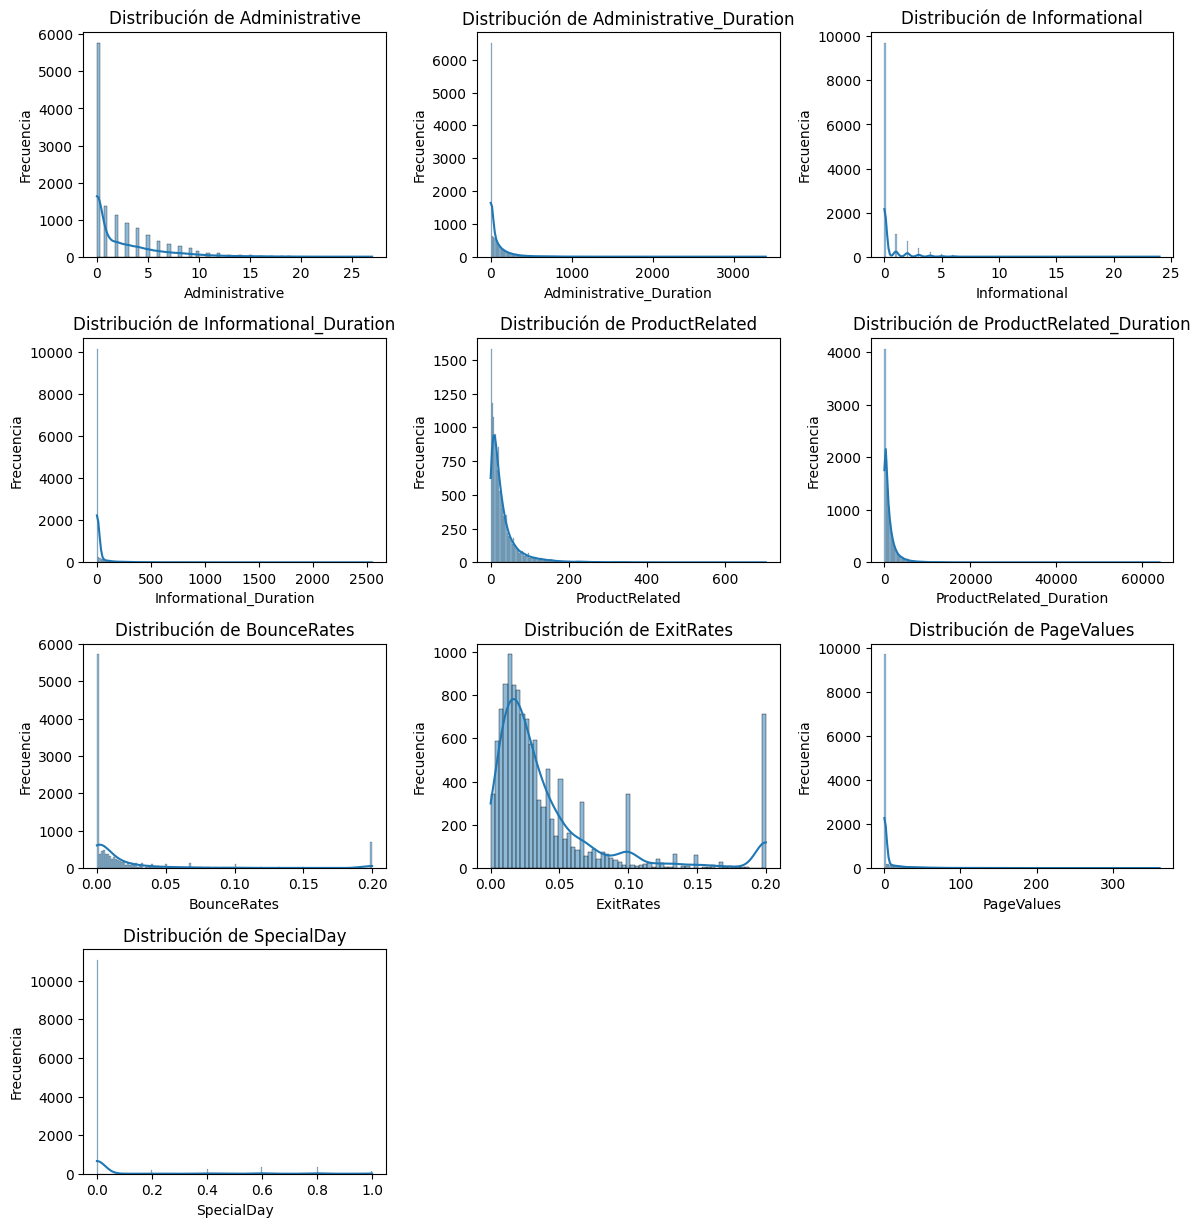

In [35]:
# Visualización de distribuciones para variables numéricas
# Crear histogramas para ver la distribución, sesgo y posibles valores extremos

fig = plt.figure(figsize=(12, 15))
for i, col in enumerate(numeric_cols):
    ax = fig.add_subplot(5, 3, i + 1) # 5 filas, 3 columnas
    sns.histplot(intention_df[col], kde=True, ax=ax)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
fig.tight_layout()
plt.show()


In [36]:
# Calcular y mostrar el sesgo (skewness) para cada variable numérica
print("\n--- Sesgo (Skewness) de Variables Numéricas ---")
print(intention_df[numeric_cols].skew().sort_values(ascending=False))


--- Sesgo (Skewness) de Variables Numéricas ---
Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
BounceRates                2.947855
ExitRates                  2.148789
Administrative             1.960357
dtype: float64


- Las variables numéricas muestran distribuciones fuertemente asimétricas a la derecha, con medianas muy cercanas a cero y colas largas en los máximos.
- El cálculo de skewness confirma un sesgo positivo marcado en casi todas las variables numéricas, siendo especialmente extremo en Informational_Duration, ProductRelated_Duration y PageValues (skewness > 6), lo que indica presencia clara de valores extremos/outliers en la cola derecha


### ¿Cómo se distribuye la variable objetivo Revenue?

In [37]:
# Calcular la distribución de la variable objetivo 'Revenue'
revenue_distribution_percentage = intention_df['Revenue'].value_counts(normalize=True) * 100
revenue_distribution_absolute = intention_df['Revenue'].value_counts()

print("--- Distribución RELATIVA de la variable objetivo 'Revenue' (% )---")
print(revenue_distribution_percentage)

print("\n--- Distribución ABSOLUTA de la variable objetivo 'Revenue' (conteo) ---")
print(revenue_distribution_absolute)

--- Distribución RELATIVA de la variable objetivo 'Revenue' (% )---
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

--- Distribución ABSOLUTA de la variable objetivo 'Revenue' (conteo) ---
Revenue
False    10422
True      1908
Name: count, dtype: int64


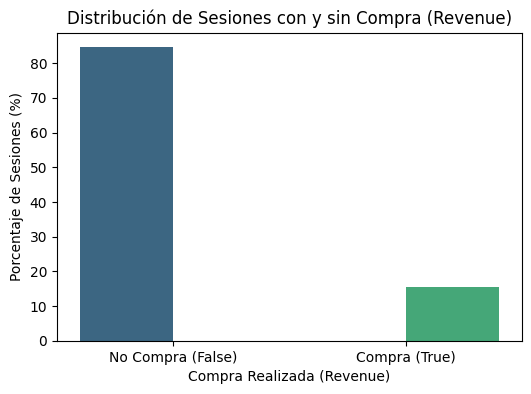

In [38]:
# Visualizar la distribución
plt.figure(figsize=(6, 4))
sns.barplot(x=revenue_distribution_percentage.index, y=revenue_distribution_percentage.values, palette='viridis', hue=revenue_distribution_percentage.index, legend=False)
plt.title('Distribución de Sesiones con y sin Compra (Revenue)')
plt.xlabel('Compra Realizada (Revenue)')
plt.ylabel('Porcentaje de Sesiones (%)')
plt.xticks(ticks=[0, 1], labels=['No Compra (False)', 'Compra (True)'])
plt.show()

- Revenue es booleana y presenta dos clases: False (10.422 sesiones) y True (1.908 sesiones). Esto implica que las sesiones con compra son minoría frente a las que no convierten.

- Al calcular la proporción relativa, se observa que cerca del 85% de los registros pertenecen a la clase negativa y solo alrededor del 15% a la clase positiva, por lo que el dataset está claramente desbalanceado.

In [39]:
# Verificar valores faltantes
print("--- Conteo de Valores Faltantes por Columna ---")
missing_values = intention_df.isnull().sum()
missing_values

--- Conteo de Valores Faltantes por Columna ---


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [40]:
# Calcular cantidad de resgistros duplicados
print("--- Cantidad de Registros Duplicados ---")
print(intention_df.duplicated().sum())

--- Cantidad de Registros Duplicados ---
125


En el análisis exploratorio se verificó que el dataset no presenta valores faltantes en ninguna de sus variables, pero sí se detectó la presencia de registros duplicados que deberán tratarse antes del modelado.

### ¿Qué relaciones existen entre las variables?

In [55]:
# Calcular la matriz de correlación para las variables numéricas y la variable objetivo
# Incluimos 'Revenue' (que es booleana y Pandas la tratará como 0 y 1 para la correlación)
columns_for_correlation = numeric_cols + ['Revenue']
correlation_matrix = intention_df[columns_for_correlation].corr()

print("--- Matriz de Correlación de Variables Numéricas y Revenue ---")
display(correlation_matrix)

--- Matriz de Correlación de Variables Numéricas y Revenue ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Revenue
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,0.138917
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,0.093587
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,0.095200
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,0.070345
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,0.158538
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,0.152373
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,-0.150673
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,-0.207071
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,0.492569
SpecialDay,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,-0.082305


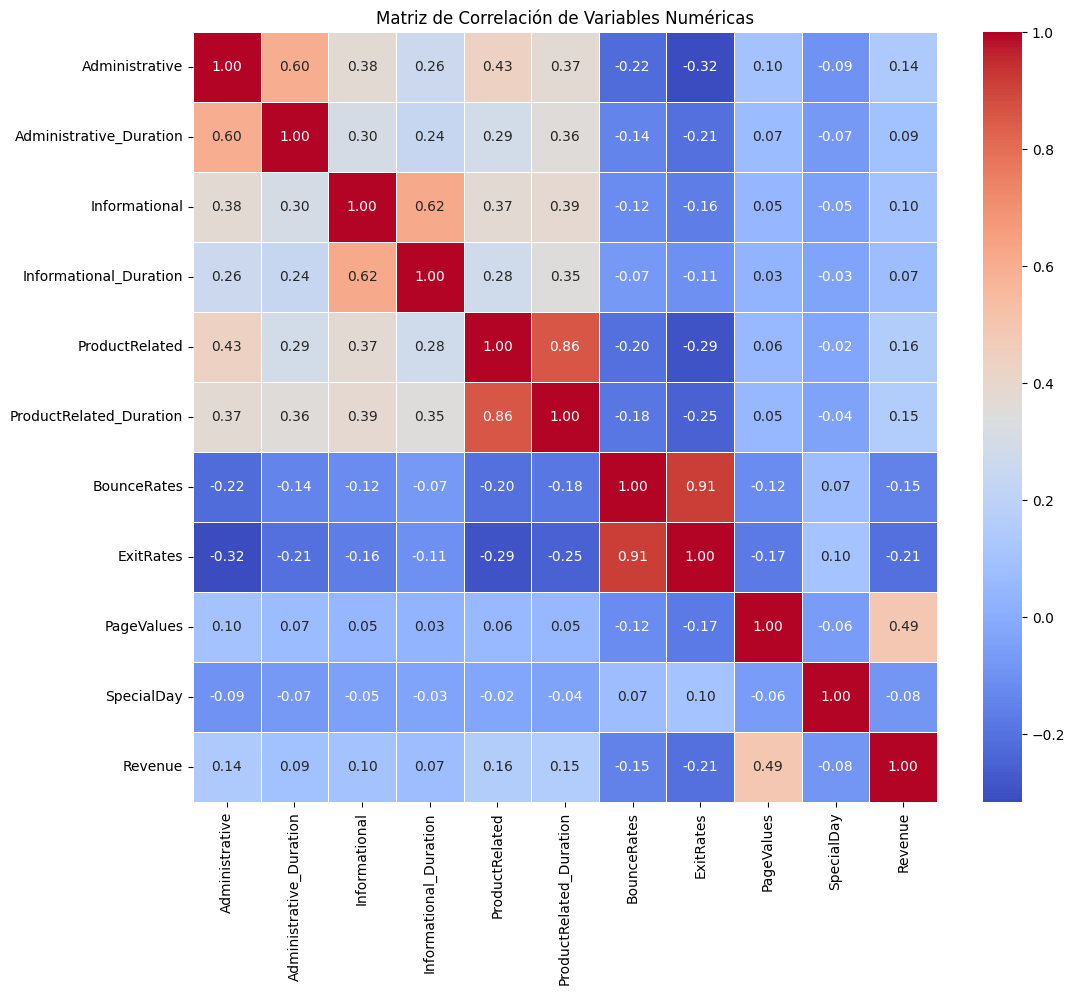

In [42]:
# Visualizar la matriz de correlación como un heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [56]:
# Correlaciones con Revenue ordenadas de mayor a menor
correlation_with_revenue = correlation_matrix['Revenue'].sort_values(ascending=False)
print("--- Correlaciones con Revenue (de mayor a menor) ---")
display(correlation_with_revenue)

--- Correlaciones con Revenue (de mayor a menor) ---


Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

- Las variables más relacionadas con Revenue son PageValues, que presenta la correlación positiva más fuerte con la variable objetivo, y en menor medida ProductRelated y ProductRelated_Duration, que muestran asociaciones positivas más débiles con la probabilidad de compra.
- Las tasas BounceRates y ExitRates se correlacionan negativamente con Revenue, indicando que mayores valores de estas métricas se asocian con menor probabilidad de conversión,

In [57]:
# Realizar crosstab para todas las variables categóricas identificadas contra 'Revenue'

# Excluir 'Revenue' de la lista de categóricas si está presente, ya que es la variable target
categorical_features_for_crosstab = [col for col in categorical_cols if col != 'Revenue']

for col in categorical_features_for_crosstab:
    print(f"\n--- Análisis de '{col}' vs. 'Revenue' ---")
    display(pd.crosstab(intention_df[col], intention_df['Revenue'], normalize="index"))


--- Análisis de 'Month' vs. 'Revenue' ---


Revenue,False,True
Month,,
Aug,0.824480,0.175520
Dec,0.874928,0.125072
Feb,0.983696,0.016304
Jul,0.847222,0.152778
June,0.899306,0.100694
Mar,0.899318,0.100682
May,0.891498,0.108502
Nov,0.746498,0.253502
Oct,0.790528,0.209472



--- Análisis de 'VisitorType' vs. 'Revenue' ---


Revenue,False,True
VisitorType,,
New_Visitor,0.750885,0.249115
Other,0.811765,0.188235
Returning_Visitor,0.860677,0.139323



--- Análisis de 'Weekend' vs. 'Revenue' ---


...

Revenue,False,True
Browser,,
1,0.851747,0.148253
2,0.846376,0.153624
3,0.952381,0.047619
4,0.823370,0.176630
5,0.815846,0.184154
6,0.885057,0.114943
7,0.877551,0.122449
8,0.844444,0.155556
9,1.000000,0.000000



--- Análisis de 'Region' vs. 'Revenue' ---


Revenue,False,True
Region,,
1,0.838703,0.161297
2,0.834507,0.165493
3,0.854765,0.145235
4,0.851946,0.148054
5,0.836478,0.163522
6,0.860870,0.139130
7,0.843627,0.156373
8,0.870968,0.129032
9,0.831703,0.168297



--- Análisis de 'TrafficType' vs. 'Revenue' ---


Revenue,False,True
TrafficType,,
1,0.893105,0.106895
2,0.783542,0.216458
3,0.912281,0.087719
4,0.845650,0.154350
5,0.784615,0.215385
6,0.880631,0.119369
7,0.700000,0.300000
8,0.723032,0.276968
9,0.904762,0.095238


### Insights de las Tablas Cruzadas (Variables Categóricas vs. Revenue)

*   **Month (Mes):** Noviembre muestra la tasa de conversión más alta (25.4%), seguido por Octubre y Septiembre, lo que sugiere una fuerte estacionalidad. Febrero tiene la tasa más baja (1.6%).
*   **VisitorType (Tipo de Visitante):** Sorprendentemente, los `New_Visitor` (Visitantes Nuevos) tienen una tasa de conversión superior (24.9%) a los `Returning_Visitor` (Visitantes Recurrentes) (13.9%). Esto podria indicar que los nuevos visitantes pueden llegar con una intención de compra más definida.
*   **Weekend (Fin de Semana):** (La salida completa fue truncada, pero la tabla cruzada de 'Weekend' vs. 'Revenue' es importante para entender cómo el comportamiento de compra difiere en fines de semana comparado con días de semana).

### ¿Cómo varía PageValues entre sesiones con y sin compra?

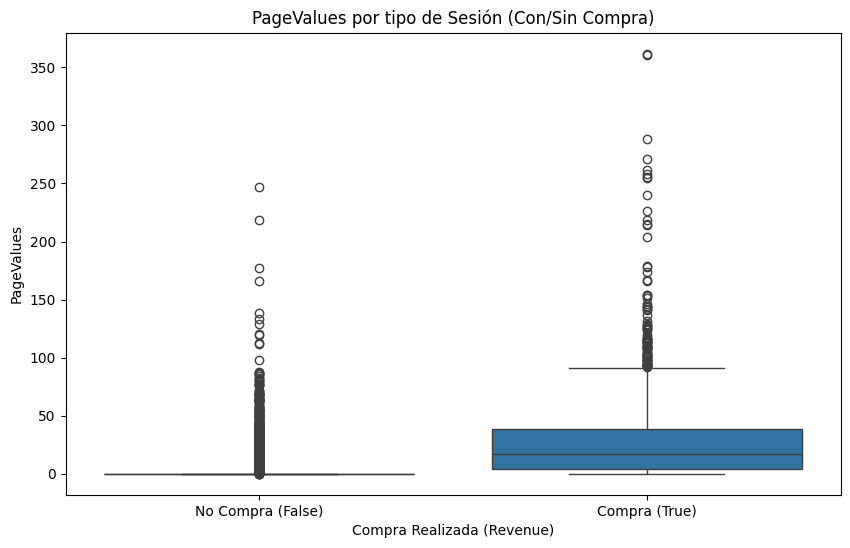

In [45]:
# Comparar PageValues entre sesiones con y sin compra (Revenue)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Revenue', y='PageValues', data=intention_df)
plt.title('PageValues por tipo de Sesión (Con/Sin Compra)')
plt.xlabel('Compra Realizada (Revenue)')
plt.ylabel('PageValues')
plt.xticks(ticks=[0, 1], labels=['No Compra (False)', 'Compra (True)'])
plt.show()


In [58]:
# Calcular y mostrar las estadísticas descriptivas por grupo de Revenue
print("--- Estadísticas de 'PageValues' por Revenue ---")
display(intention_df.groupby('Revenue')['PageValues'].describe())

--- Estadísticas de 'PageValues' por Revenue ---


,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


Las sesiones con compra (True) presentan valores de PageValues notablemente más altos que las sesiones sin compra (False), cuya mediana es prácticamente cero. Esto refuerza que PageValues es uno de los predictores más relevantes para la variable objetivo Revenue.

### ¿BounceRates y ExitRates son más altos en sesiones que no convierten?

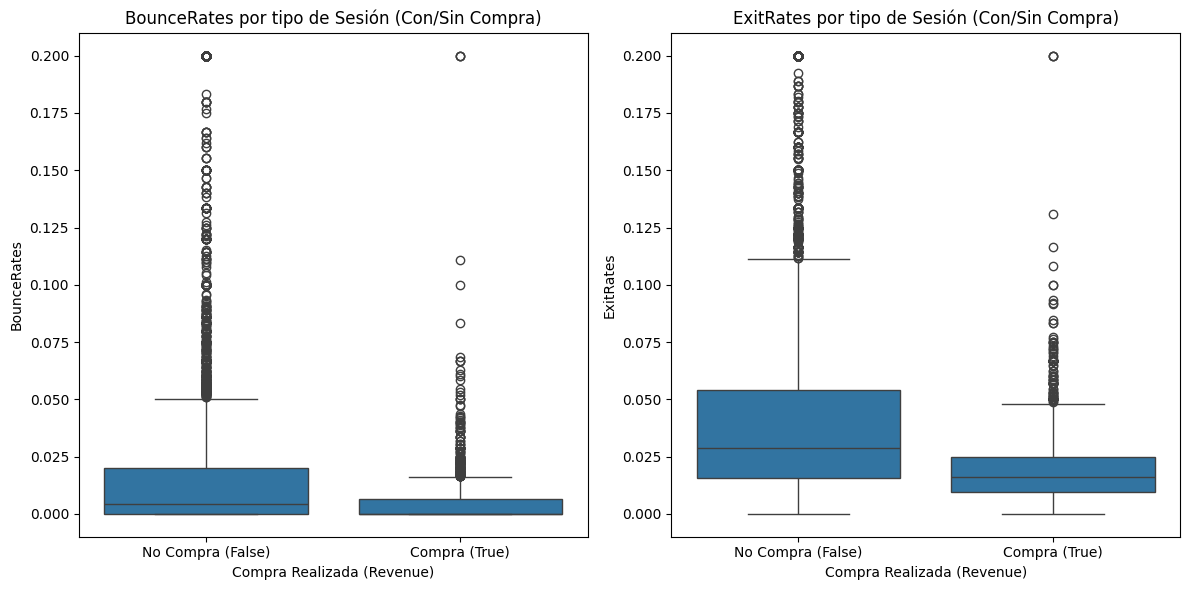

In [47]:
# Comparar BounceRates entre sesiones con y sin compra (Revenue)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.boxplot(x='Revenue', y='BounceRates', data=intention_df)
plt.title('BounceRates por tipo de Sesión (Con/Sin Compra)')
plt.xlabel('Compra Realizada (Revenue)')
plt.ylabel('BounceRates')
plt.xticks(ticks=[0, 1], labels=['No Compra (False)', 'Compra (True)'])
#plt.ylim(0, intention_df['BounceRates'].quantile(0.99)) # Limitar el eje Y para mejor visualización

# Comparar ExitRates entre sesiones con y sin compra (Revenue)
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(x='Revenue', y='ExitRates', data=intention_df)
plt.title('ExitRates por tipo de Sesión (Con/Sin Compra)')
plt.xlabel('Compra Realizada (Revenue)')
plt.ylabel('ExitRates')
plt.xticks(ticks=[0, 1], labels=['No Compra (False)', 'Compra (True)'])
#plt.ylim(0, intention_df['ExitRates'].quantile(0.99)) # Limitar el eje Y para mejor visualización

plt.tight_layout()
plt.show()


In [59]:
# Calcular y mostrar las estadísticas descriptivas por grupo de Revenue
print("--- Estadísticas de 'BounceRates' por Revenue ---")
display(intention_df.groupby('Revenue')['BounceRates'].describe())

print("\n--- Estadísticas de 'ExitRates' por Revenue ---")
display(intention_df.groupby('Revenue')['ExitRates'].describe())

--- Estadísticas de 'BounceRates' por Revenue ---


,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.025317,0.051877,0.0,0.0,0.004255,0.020000,0.2
True,1908.0,0.005117,0.012185,0.0,0.0,0.000000,0.006452,0.2



--- Estadísticas de 'ExitRates' por Revenue ---


,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.047378,0.051231,0.0,0.015560,0.028571,0.053846,0.2
True,1908.0,0.019555,0.016463,0.0,0.009521,0.016000,0.025000,0.2


Tanto BounceRates como ExitRates son más altos en sesiones sin compra (False). Los boxplots muestran medianas y rangos intercuartílicos claramente superiores en el grupo No Compra, confirmando que tasas de rebote y salida elevadas se asocian a sesiones que no convierten.

### ¿Cómo se distribuyen las compras a lo largo de los meses del año?

In [49]:
# Calcular la tasa de conversión por mes
conversion_rate_by_month = intention_df.groupby('Month', observed=False)['Revenue'].apply(lambda x: x.astype(int).mean())
conversion_rate_by_month

Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64

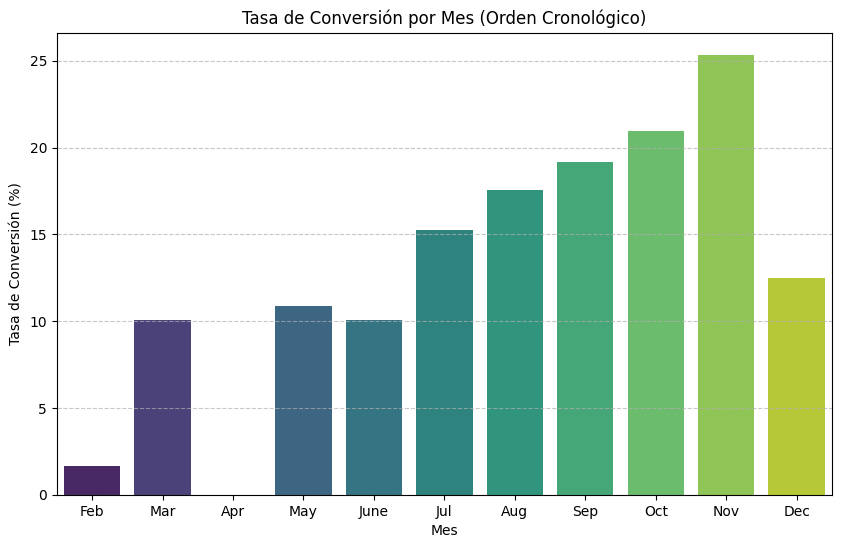

In [50]:
# Visualizar distribución de compras a lo largo del año, ordenadas por mes
month_order = ['Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] # Reordenar para visualización cronológica

# Reindexar y convertir a porcentaje
conversion_rate_by_month_ordered = conversion_rate_by_month.reindex(month_order).mul(100)

plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_rate_by_month_ordered.index, y=conversion_rate_by_month_ordered.values, palette='viridis', hue=conversion_rate_by_month_ordered.index, legend=False)
plt.title('Tasa de Conversión por Mes (Orden Cronológico)')
plt.xlabel('Mes')
plt.ylabel('Tasa de Conversión (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- La tasa de conversión crece progresivamente a lo largo del año, alcanzando su pico en noviembre (~25.5%), lo que sugiere un fuerte efecto estacional asociado a fechas comerciales clave (Black Friday, Cyber Monday).
- Abril y enero no registran conversiones en el dataset. Diciembre cae respecto a noviembre (~12.5%), posiblemente porque muchas compras ya fueron adelantadas.

### ¿Los visitantes recurrentes (Returning_Visitor) compran más que los visitantes nuevos (New_Visitor)?

In [51]:
# Calcular distribucion de compras por tipo de visitante
conversion_rate_by_visitor = intention_df.groupby('VisitorType', observed=False)['Revenue'].apply(lambda x: x.astype(int).mean())
conversion_rate_by_visitor

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

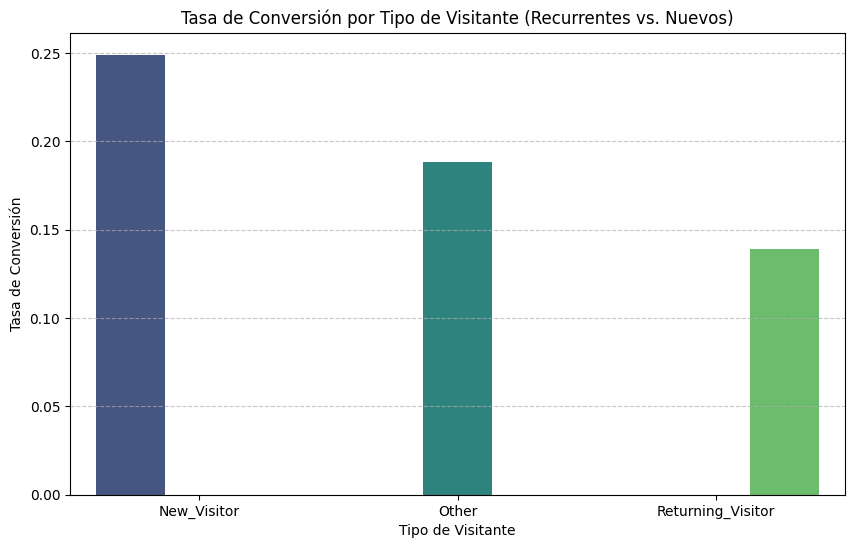

In [52]:
# Visualizar distribucion de compra y no compra por tipo de visitante
plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_rate_by_visitor.index, y=conversion_rate_by_visitor.values, palette='viridis',
            hue=conversion_rate_by_visitor  .index, legend=False)
plt.title('Tasa de Conversión por Tipo de Visitante (Recurrentes vs. Nuevos)')
plt.xlabel('Tipo de Visitante')
plt.ylabel('Tasa de Conversión')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Contrariamente a lo esperado, los visitantes nuevos (New_Visitor) presentan la mayor tasa de conversión (24.9%), seguidos por Other (18.8%), mientras que los visitantes recurrentes (Returning_Visitor) tienen la tasa más baja (13.9%). Esto sugiere que los visitantes nuevos llegan con mayor intención de compra, posiblemente atraídos por campañas o promociones puntuales.

### ¿Cómo varía la tasa de conversión entre fines de semana y días de semana?

Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64

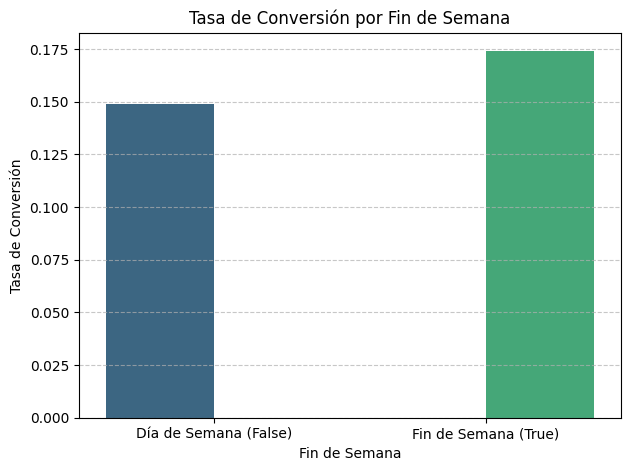

In [60]:
conversion_rate_by_weekend = intention_df.groupby('Weekend', observed=False)['Revenue'].apply(lambda x: x.astype(int).mean())
display(conversion_rate_by_weekend)

plt.figure(figsize=(7, 5))
sns.barplot(x=conversion_rate_by_weekend.index, y=conversion_rate_by_weekend.values, palette='viridis', hue=conversion_rate_by_weekend.index, legend=False)
plt.title('Tasa de Conversión por Fin de Semana')
plt.xlabel('Fin de Semana')
plt.ylabel('Tasa de Conversión')
plt.xticks(ticks=[0, 1], labels=['Día de Semana (False)', 'Fin de Semana (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- La tasa de conversión es ligeramente superior en fines de semana (16.7%) en comparación con los días de semana (15.1%). Aunque la diferencia no es tan pronunciada como la estacionalidad o el tipo de visitante, sugiere que los usuarios que navegan durante el fin de semana tienen una probabilidad marginalmente mayor de completar una compra.

# Conclusiones del Análisis Exploratorio
- Dataset: 18 atributos (10 numéricos, 8 categóricos), sin valores faltantes pero con registros duplicados a tratar en el preprocesamiento.

- Desbalance de clases: La variable objetivo Revenue está desbalanceada (85% No Compra / 15% Compra), lo que deberá considerarse en la selección de métricas y estrategia de muestreo del modelo.

- Distribuciones sesgadas: La mayoría de las variables numéricas presentan sesgo positivo marcado y valores extremos, especialmente las variables de duración y PageValues.

- Predictores más relevantes: PageValues es la variable con mayor correlación con Revenue. BounceRates y ExitRates se correlacionan negativamente con la conversión, y entre sí presentan una correlación muy alta (0.91), lo que sugiere evaluar multicolinealidad.

- Estacionalidad: La tasa de conversión crece a lo largo del año con un pico en noviembre (25.5%), evidenciando un fuerte efecto estacional ligado a fechas comerciales clave.

- Tipo de visitante: Los visitantes nuevos convierten más (24.9%) que los recurrentes (13.9%), resultado contraintuitivo que puede ser relevante para el modelo.